# Branching networks and the layout plotter

Real street grids fork. This notebook builds a district cooling network that does,
checks that it is well posed before solving it, draws it as a plan, and runs it
through a day of Riyadh-style July weather.

The network in `configs/config_branching_grid.yaml`:

```
central plant
     |
[downtown trunk]  city hall -> conference centre
     |
     +--(north)--> [north spur]  north tower -> teaching block --> bypass
     |
     +--(east) --> [east spur]   airport hotel
                        |
                        +--(south)--> [south leg]  exhibition hall --> bypass
                        |
                        +-----------> satellite plant (chiller + cold store)
```

Six buildings, four branches, and all three kinds of terminal a branch can end in.

## What a fork actually changes

Three things, and each one is a place a model can go quietly wrong.

**Hydraulics.** Every terminal spans the same two nodes, its branch's end-of-line
supply node and end-of-line return node. So a fork with *k* terminals puts *k* paths
in parallel between one pair of nodes and adds *k - 1* loops. In a loop you may fix
the pressure drop of every element but one. A single street that solves happily with
its end bypass pinned at `dp = 0` therefore stops solving the moment it forks with
both bypasses pinned, and TESPy's complaint about it is a dump of variable names.
DisCoolPy checks the graph first and says which element to free.

**Order.** "Which building is on which street, and in what order" stops being
obvious. Each branch lists its own buildings, and the first name is the first tap
after the branch inlet.

**Energy.** A satellite plant is a second evaporator in the chilled-water loop. The
loop has exactly one free energy variable and that is the central machine's duty, so
a satellite's duty stays asserted, which is fine, because how hard a distributed
plant runs is a dispatch decision rather than a physical consequence.

In [1]:
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from discoolpy import (
    analyse_network_topology,
    build_system,
    compute_layout,
    load_yaml_config,
    make_branch_specs,
    make_weather_and_load_profiles,
    network_design_mass_flows,
    network_topology,
    plot_network,
    run_configured_case,
)

warnings.filterwarnings('ignore', category=FutureWarning)
# TESPy logs every part-load excursion outside a compressor characteristic's
# range. It extrapolates correctly; the notice is just noise here.
logging.getLogger('TESPyLogger').setLevel(logging.ERROR)
pd.set_option('display.width', 130)

CONFIG = Path('..') / 'configs' / 'config_branching_grid.yaml'
config = load_yaml_config(CONFIG)
config['profiles']['periods'] = 48        # one day at 30 min
config['outputs']['output_dir'] = '../outputs/branching_notebook'
print(config['metadata']['description'].strip())

A district cooling network laid out on a street grid that forks. The trunk leaves the central plant heading east, serves two buildings, and splits at the first junction into a north spur and an east spur. The east spur forks again: one leg carries on south to a dead-end bypass, the other feeds a satellite plant with its own chiller, cooling tower and chilled-water store. Six buildings, four branches, three kinds of terminal.


## 1. Reading the tree

`make_branch_specs` normalises the `branch:` section into a tree, resolving each
branch's building list into the top-level `buildings:` section and filling in the
settings a child inherits from its parent. Nothing here touches TESPy, which is what
makes the whole scenario checkable before a single component exists.

In [2]:
root = make_branch_specs(config)
labels = [b['label'] for b in config['buildings']]
flows = network_design_mass_flows(config, root)

def show(spec, depth=0):
    pad = '    ' * depth
    print(f"{pad}[{spec.label}]  {flows[spec.label]['inlet']:6.2f} kg/s in")
    for order, index in enumerate(spec.building_indices, start=1):
        print(f'{pad}    {order}. {labels[index]}')
    for terminal in spec.terminals:
        if terminal.child is not None:
            show(terminal.child, depth + 1)
        else:
            m = flows[spec.label]['terminals'][terminal.label]
            print(f'{pad}    -> {terminal.kind}: {terminal.label} ({m:.2f} kg/s)')

show(root)

[downtown trunk]   78.55 kg/s in
    1. city hall
    2. conference centre
    [north spur]   19.59 kg/s in
        1. north tower
        2. teaching block
        -> bypass: north dead end (0.08 kg/s)
    [east spur]   37.98 kg/s in
        1. airport hotel
        [south leg]    8.53 kg/s in
            1. exhibition hall
            -> bypass: south dead end (0.06 kg/s)
        -> plant: airport satellite (14.00 kg/s)


Note what did *not* have to be specified: no sub-branch names a mass flow. A branch
carries whatever its subtree consumes, so only the leaves, bypasses and satellite
plants need a number. That is also exactly the set of mass flows TESPy needs
specified, which is not a coincidence: both counts come from the same tree.

## 2. Is it well posed?

`network_topology` projects the scenario onto its pressure graph, and
`analyse_network_topology` counts loops and looks for a redundant specification with
union-find. This runs in milliseconds and it is the difference between a readable
sentence and a TESPy cycle dump.

In [3]:
report = analyse_network_topology(network_topology(config))
print(report.message())
print()
print(f'branches      : {report.n_branches}')
print(f'forks         : {report.n_forks}')
print(f'unknown nodes : {report.n_nodes}')
print(f'elements      : {report.n_edges}  ({report.n_specified} of them specified)')
print(f'free loops    : {report.n_loops}')

Network pressure specification is consistent: 12 specified element(s) across 4 branches for 12 unknown pressure node(s), 9 loop(s) left free.

branches      : 4
forks         : 2
unknown nodes : 12
elements      : 21  (12 of them specified)
free loops    : 9


### Breaking it on purpose

Pin both end bypasses at `dp = 0`, the setting a single-street scenario uses
happily, and the fork makes it over-determined. The message names the offending
elements and says what to do about them.

In [4]:
import copy

broken = copy.deepcopy(config)
broken['branch']['terminals'][0]['terminals'][0]['dp'] = 0.0
broken['branch']['terminals'][1]['terminals'][0]['terminals'][0]['dp'] = 0.0

try:
    build_system(broken)
except ValueError as error:
    print(error)

Over-determined hydraulics: 2 redundant pressure specification(s). The network (4 branches) has 9 independent hydraulic loop(s), so exactly 12 of the 21 elements may fix a pressure drop; 14 do.
  - 'east spur/return_1' (darcy_group (L+D+ks)) closes a loop whose drop is already fixed by: south leg/return_1, south leg/south dead end, south leg/supply_1, east spur/supply_1, north spur/return_1, north spur/return_2, north spur/north dead end, north spur/supply_2, north spur/supply_1
  - 'return_2' (darcy_group (L+D+ks)) closes a loop whose drop is already fixed by: north spur/return_1, north spur/return_2, north spur/north dead end, north spur/supply_2, north spur/supply_1, supply_2, supply_1, return_1
  Fix: remove the pressure specification from one element in each loop listed above (set the building's 'pr' to null, drop 'pr'/'L,D,ks' from the pipe, or set a terminal's 'dp' to null so its balancing valve reports the drop). Its pressure drop then becomes a solved output.
  Note: this netw

Setting `branch.auto_relax_pressure: true` lets DisCoolPy repair it instead, and say
what it released. It only ever frees a balancing valve, a building leg or a bypass
-- because those are set by a valve in reality. It never quietly rewrites pipe
geometry, because conflicting geometry means the scenario itself is wrong.

In [5]:
broken['branch']['auto_relax_pressure'] = True
repaired = build_system(broken)
for note in repaired.notes:
    print('*', note)

* Released terminal 'south dead end' pressure specification on branch 'south leg' to resolve an over-determined hydraulic loop; its balancing valve now reports the drop the loop needs.
* Released terminal 'north dead end' pressure specification on branch 'north spur' to resolve an over-determined hydraulic loop; its balancing valve now reports the drop the loop needs.
* Chiller duty is a solved output (plant_control='supply_temperature'); it equals building demand + pipe gains + pump heat + storage exchange - satellite plant duty.
* 1 satellite plant(s) carry 180.0 kW of the district duty; their evaporator duties stay asserted because the loop has only one free energy variable and that is the main plant.


## 3. Drawing it

Each pipe carries a length `L` and a bearing `heading_deg`, measured
counter-clockwise from east. Neither changes anything the solver sees; they exist so
the network can be drawn as the street grid it represents.

| Component | Marker |
|---|---|
| Chiller / plant | square |
| Cooling tower | octagon |
| Cold storage | circle |
| Building | triangle |
| Split / merge | point |
| Pump | diamond |
| Pipe | line (supply and return as a parallel pair) |

`plot_network` takes the system and draws it. It does not need a solved network,
the layout is a property of the scenario, so it is worth looking at *before* the
first solve, when a spur pointing the wrong way is still cheap to fix.

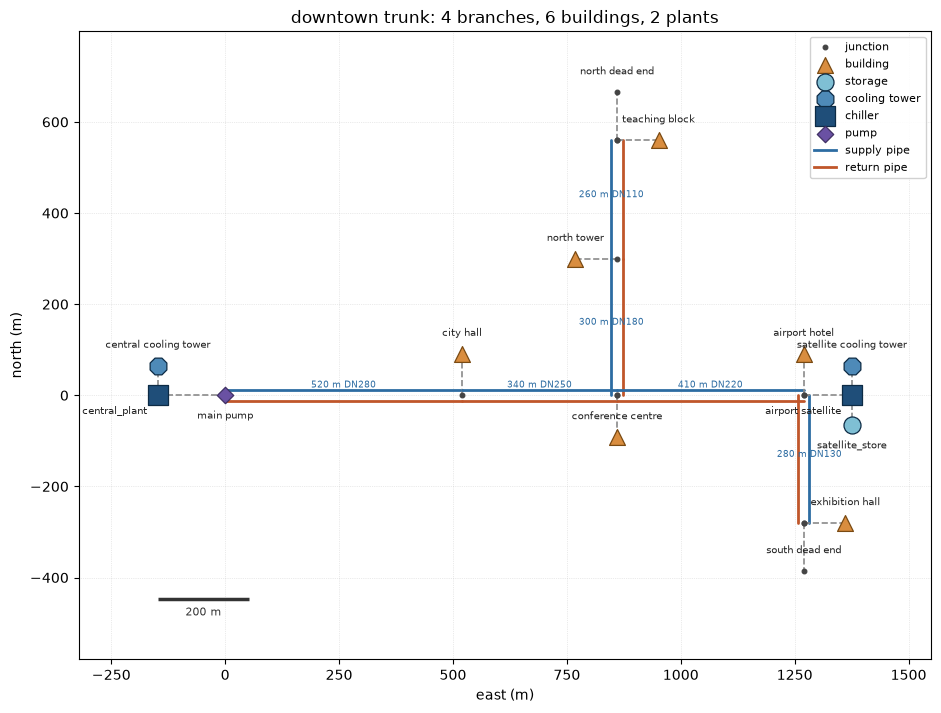

In [6]:
system = build_system(config)
ax = plot_network(system, annotate_pipes=True)
plt.show()

The drawing is to scale and the axes are in metres, so it can be checked against a
site plan. `compute_layout` gives the same thing as data when you want to write it
out or check a coordinate.

In [7]:
layout = compute_layout(system)
print('geometry complete:', layout.geometry_is_complete)
nodes = pd.DataFrame(layout.to_records()['nodes'])
nodes[nodes['kind'].isin(['building', 'chiller', 'storage'])][
    ['kind', 'label', 'branch', 'x_m', 'y_m']
].round(1)

geometry complete: True


,kind,label,branch,x_m,y_m
0,chiller,central_plant,NaN,-147.7,0.0
4,building,city hall,downtown trunk,520.0,91.4
6,building,conference centre,downtown trunk,860.0,-91.4
9,building,north tower,north spur,768.6,300.0
11,building,teaching block,north spur,951.4,560.0
15,building,airport hotel,east spur,1270.0,91.4
18,building,exhibition hall,south leg,1361.4,-280.0
21,chiller,airport satellite,east spur,1375.5,0.0
23,storage,satellite_store,east spur,1375.5,-65.4


A scenario with no geometry at all still draws. Unknown lengths fall back to a
nominal segment and terminals fan out around their parent's heading, so the result is
schematic, and the title says so rather than pretending otherwise.

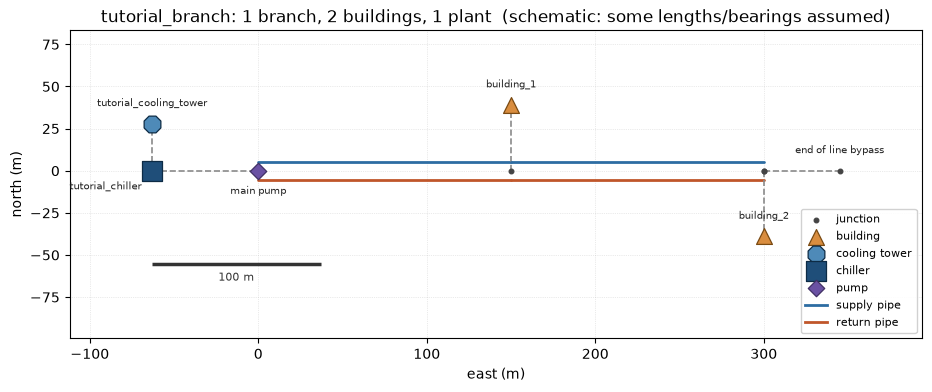

In [8]:
tutorial = build_system(load_yaml_config(Path('..') / 'configs' / 'config_tutorial.yaml'))
ax = plot_network(tutorial)
plt.show()

## 4. The design point

The closure check is the one number to look at first. Everything entering the
chilled water must leave through an evaporator:

$$Q_{\\mathrm{central}} + Q_{\\mathrm{satellite}} - Q_{\\mathrm{store}}
= Q_{\\mathrm{buildings}} + Q_{\\mathrm{pipes}} + P_{\\mathrm{pump}}$$

The satellite enters with the opposite sign because it takes duty out of the loop
before it reaches the central machine.

In [9]:
system.network.solve(mode='design', max_iter=400)
assert system.network.converged

gains = system.branch.heat_gain_report()
sat = system.branch.satellite_report()
buildings = sum(b.component.Q.val for b in system.buildings)
pump = system.branch.pump.P.val

print(f'buildings            {buildings/1e3:9.2f} kW')
print(f'pipe gain            {gains["total_heat_gain_W"]/1e3:9.2f} kW')
print(f'pump heat            {pump/1e3:9.2f} kW')
print(f'satellite delivers   {-sat["total_delivered_Q_W"]/1e3:9.2f} kW')
print( '                     ---------')
print(f'central plant duty   {system.chiller.solved_Q_evap_W/1e3:9.2f} kW')
residual = (system.chiller.solved_Q_evap_W + sat['total_Q_evap_W']
            - sat['total_storage_Q_W'] - buildings
            - gains['total_heat_gain_W'] - pump)
print(f'residual             {residual:9.2e} W')

buildings              1750.00 kW
pipe gain                28.46 kW
pump heat                17.28 kW
satellite delivers     -180.00 kW
                     ---------
central plant duty     1615.74 kW
residual              6.44e-08 W


### Heat gain, branch by branch

Aggregating gain over the whole network hides where it comes from. The south leg is
the shortest route in the network and it picks up the most heat per metre, because it
crosses a service bridge in 42 degC air instead of being buried in 31 degC soil.

In [10]:
per_pipe = system.branch.heat_gain_report()['per_pipe_W']
rows = []
for branch in system.branches:
    prefix = '' if branch is system.branch else f'{branch.label}/'
    keys = [f'{prefix}{k}' for k, _ in branch.pipe_items()]
    gain = sum(per_pipe.get(k, 0.0) for k in keys)
    length = sum((branch.pipe_lengths or {}).get(k, 0.0) for k, _ in branch.pipe_items())
    rows.append({
        'branch': branch.label,
        'route_m': length,
        'buildings_kW': sum(b.component.Q.val for b in branch.buildings) / 1e3,
        'gain_kW': gain / 1e3,
        'gain_W_per_m': gain / length,
    })
pd.DataFrame(rows).round(3)

,branch,route_m,buildings_kW,gain_kW,gain_W_per_m
0,downtown trunk,1720.0,570.0,12.441,7.233
1,north spur,1120.0,530.0,5.581,4.983
2,east spur,820.0,420.0,5.522,6.734
3,south leg,560.0,230.0,4.919,8.783


### Hydraulic feasibility

Building mass flows are specified, so TESPy will return whatever pressures balance
the equations, including a *negative* drop across a building leg, which means the
pump could not actually push that flow and the far building would be starved. The
feasibility check catches that; without it the only symptom is a stream of "Invalid
value for pr" warnings that is easy to dismiss as noise.

In [11]:
print(system.branch.pressure_feasibility()['message'])
print()
for branch in system.branches:
    for building in branch.buildings:
        dp = building.inlet.p.val - building.outlet.p.val
        print(f'{branch.label:<16} {building.label:<20} valve authority {dp:5.2f} bar')

Branch pressure specification is feasible: every element drops pressure along the flow direction.

downtown trunk   city hall            valve authority  1.20 bar
downtown trunk   conference centre    valve authority  0.82 bar
north spur       north tower          valve authority  0.65 bar
north spur       teaching block       valve authority  0.39 bar
east spur        airport hotel        valve authority  0.52 bar
south leg        exhibition hall      valve authority  0.35 bar


## 5. A day of operation

Now the time series. The satellite is dispatched `proportional`, so what it *delivers*
follows the district's load, while its store absorbs the difference between that and
the flat duty it aims the chiller at. That is the reason to put a store at a satellite:
the machine runs level while its output follows demand.

In [12]:
profile = make_weather_and_load_profiles(config)
results = run_configured_case(config, profile, 'grid', use_storage=False, progress=False)
print('max |closure residual| :', f"{results['chw_energy_residual_W'].abs().max():.2e} W")
results[['timestamp', 'actual_building_total_Q_W', 'chiller_Q_evap_W',
         'satellite_Q_evap_W', 'satellite_delivered_Q_W', 'fleet_cop']].iloc[::6].round(1)

max |closure residual| : 1.76e-08 W


,timestamp,actual_building_total_Q_W,chiller_Q_evap_W,satellite_Q_evap_W,satellite_delivered_Q_W,fleet_cop
0,2026-07-14T00:00:00,971862.7,916302.1,150000.0,99963.0,3.5
6,2026-07-14T03:00:00,818889.1,778725.5,150000.0,84228.6,3.4
12,2026-07-14T06:00:00,791244.5,753870.1,150000.0,81385.1,3.3
18,2026-07-14T09:00:00,1163180.5,1087361.0,122973.3,119641.4,3.6
24,2026-07-14T12:00:00,1533557.2,1419735.5,150000.0,157737.3,3.9
30,2026-07-14T15:00:00,1663069.1,1536304.2,150000.0,171058.5,3.9
36,2026-07-14T18:00:00,1485945.6,1377803.0,150000.0,152840.1,3.8
42,2026-07-14T21:00:00,1243587.6,1160329.7,150000.0,127911.9,3.7


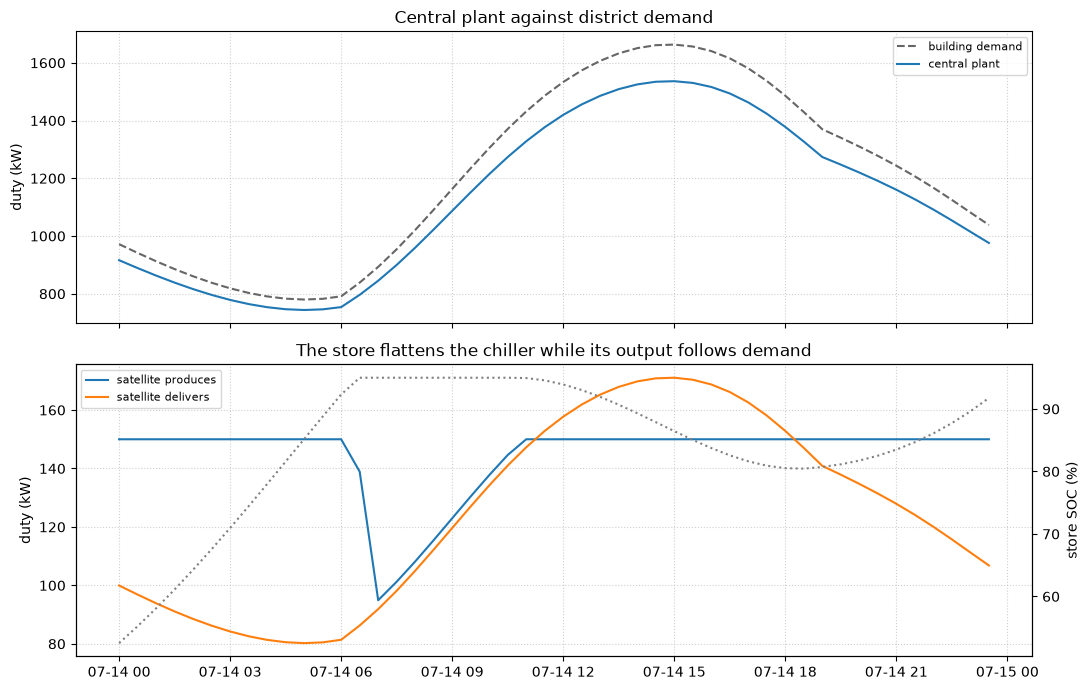

In [13]:
index = pd.to_datetime(results['timestamp'])
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(index, results['actual_building_total_Q_W'] / 1e3, '--', color='0.4',
             label='building demand')
axes[0].plot(index, results['chiller_Q_evap_W'] / 1e3, label='central plant')
axes[0].set_ylabel('duty (kW)')
axes[0].legend(fontsize=8)
axes[0].set_title('Central plant against district demand')

axes[1].plot(index, results['satellite_Q_evap_W'] / 1e3, label='satellite produces')
axes[1].plot(index, results['satellite_delivered_Q_W'] / 1e3, label='satellite delivers')
soc = [c for c in results.columns if c.endswith('_storage_soc')]
twin = axes[1].twinx()
twin.plot(index, results[soc[0]] * 100, color='0.5', linestyle=':', label='store SOC')
twin.set_ylabel('store SOC (%)')
axes[1].set_ylabel('duty (kW)')
axes[1].legend(fontsize=8, loc='upper left')
axes[1].set_title('The store flattens the chiller while its output follows demand')
for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()
plt.show()

In [14]:
produced = results['satellite_Q_evap_W']
delivered = results['satellite_delivered_Q_W']
print(f'satellite output  : {delivered.min()/1e3:6.1f} - {delivered.max()/1e3:6.1f} kW  (sd {delivered.std()/1e3:.1f})')
print(f'satellite chiller : {produced.min()/1e3:6.1f} - {produced.max()/1e3:6.1f} kW  (sd {produced.std()/1e3:.1f})')
print(f'correlation of delivered duty with district load: {delivered.corr(results["actual_building_total_Q_W"]):.3f}')

satellite output  :   80.2 -  171.1 kW  (sd 31.9)
satellite chiller :   94.9 -  150.0 kW  (sd 13.4)


correlation of delivered duty with district load: 1.000


## 6. What does the satellite buy?

The honest way to answer is to run the same network with a plain bypass in the
satellite's place with the same slipstream and the same hydraulics but no chiller, then subtract.

In [15]:
no_plant = copy.deepcopy(config)
east = no_plant['branch']['terminals'][1]
east['terminals'][1] = {'type': 'bypass', 'label': 'airport dead end',
                        'm_kg_s': 14.0, 'dp': None, 'heading_deg': 0}
baseline = run_configured_case(no_plant, profile, 'no_satellite',
                               use_storage=False, progress=False)

hours = float(results['resolution_hours'].iloc[0])
comparison = pd.DataFrame({
    'without satellite': {
        'central peak duty (kW)': baseline['chiller_Q_evap_W'].max() / 1e3,
        'central peak power (kW)': baseline['compressor_power_W'].max() / 1e3,
        'fleet peak power (kW)': baseline['total_compressor_power_W'].max() / 1e3,
        'fleet energy (kWh)': baseline['total_compressor_power_W'].sum() * hours / 1e3,
        'mean fleet COP': baseline['fleet_cop'].mean(),
    },
    'with satellite': {
        'central peak duty (kW)': results['chiller_Q_evap_W'].max() / 1e3,
        'central peak power (kW)': results['compressor_power_W'].max() / 1e3,
        'fleet peak power (kW)': results['total_compressor_power_W'].max() / 1e3,
        'fleet energy (kWh)': results['total_compressor_power_W'].sum() * hours / 1e3,
        'mean fleet COP': results['fleet_cop'].mean(),
    },
})
comparison['change %'] = (comparison['with satellite'] / comparison['without satellite'] - 1) * 100
comparison.round(2)

,without satellite,with satellite,change %
central peak duty (kW),1707.08,1536.30,-10.00
central peak power (kW),437.50,393.70,-10.01
fleet peak power (kW),437.50,437.94,0.10
fleet energy (kWh),8127.96,8345.77,2.68
mean fleet COP,3.67,3.64,-0.82


Read that carefully. The satellite takes about 10 % off the *central* machine's peak
duty and power, which is what defers a plant expansion, but the *fleet* peak barely
moves and fleet energy goes up, because the satellite is a smaller, less efficient
machine than the central one.

That is the honest answer, and it is the answer the model should give. A satellite
plant moves duty; it does not create it. It earns its place when it defers central
capacity, when it avoids pumping and pipe gain on a long index run, or when its
condenser sits somewhere cooler, not automatically. Changing `T_cond_degC` or
`eta_s` on the satellite in the config and re-running this cell is the quickest way
to see where the crossover is.

## 7. Writing your own forking scenario

The whole grammar is one key. A branch that names no `terminals` ends in a single
bypass, which is what every pre-branching scenario means and what it keeps meaning.
Adding `terminals` turns it into the root of a tree:

```yaml
branch:
  label: trunk
  buildings: [first tap, second tap]   # in order along the street
  pipe_model: darcy
  heat_model: ua
  origin_m: [0, 0]
  heading_deg: 0
  pipes:
    supply_1: {L: 520, D: 0.28, ks: 5.0e-5, heading_deg: 0}
    supply_2: {L: 340, D: 0.25, ks: 5.0e-5, heading_deg: 0}
    return_2: {L: 340, D: 0.25, ks: 5.0e-5}
    return_1: {L: 520, D: 0.28, ks: 5.0e-5}
  terminals:
    - type: branch                    # the street forks
      label: north spur
      buildings: [third tap]
      heading_deg: 90
      pipes:
        supply_1: {L: 300, D: 0.18, ks: 5.0e-5, heading_deg: 90}
        return_1: {L: 300, D: 0.18, ks: 5.0e-5}
      terminals:
        - type: bypass
          m_kg_s: 0.08
          dp: null                    # free, so it balances its own loop
    - type: plant                     # ...and ends at a distributed plant
      label: satellite
      m_kg_s: 14.0
      Q_evap_kW: 180
      dispatch: proportional
      dp: null
      chiller: {T_evap_degC: 1.0, T_cond_degC: 46.0, eta_s: 0.72}
      cooling_tower: {approach_temperature_K: -6.0}
      storage: {enabled: true, capacity_kWh: 900, coupling: hydraulic, ...}
```

Four rules cover almost everything that goes wrong:

1. **Every building belongs to exactly one branch**, and the branch's own list sets
   the tap order. A building on no branch, or on two, is refused by name.
2. **Only leaves name a mass flow.** A bypass and a satellite need `m_kg_s`; a
   sub-branch carries whatever its subtree consumes.
3. **Free the balancing valves.** Set `dp: null` on bypasses and satellite legs and
   let the pipes fix the hydraulics. Pin one and a fork is over-determined.
4. **A satellite's duty is asserted.** Give it `Q_evap_kW`; the loop's one free energy
   variable is the central plant.

A branch may also carry **no buildings at all**. It is then a trunk link with one
supply and one return pipe, useful when a main runs some distance before its first
junction.